In [1]:
import inspect
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

from jwst import datamodels

from tqdm.auto import tqdm

In [2]:
import os
os.environ['STPSF_PATH'] = os.path.expanduser('~/.cache/stpsf-data')

import stpsf

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')  # the ra and dec would have a delta in an inference loop so is different each time
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

The below should be replaced with ``stpsf.setup_sim_to_match_file(str(n6791fits[0]))`` once that works

In [4]:
nrs = stpsf.NIRSpec()
nrs.detector = dm0.meta.instrument.detector
nrs.filter = dm0.meta.instrument.filter
nrs.disperser = dm0.meta.instrument.grating

xdet, ydet = swcs.transform('detector', 'sca', *np.indices(slit.data.shape)[::-1])
nrs.detector_position = (np.mean(xdet), np.mean(ydet))

nrs.load_wss_opd_by_date(Time(dm0.meta.exposure.mid_time, format='mjd'))

nrs.image_mask = 'Single MSA open shutter'

iterating query, tdelta=3.0

MAST OPD query around UTC: 60136.5904089294
                        MJD: 60136.5904089294

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2023071203-NRCA3_FP1-1.fits
	Date (MJD):	 60136.5363
	Delta time:	 -0.0542 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/R2023071403-NRCA3_FP1-1.fits
	Date (MJD):	 60138.8979
	Delta time:	 2.3075 days
User requested choosing OPD time closest in time to 60136.5904089294, which is R2023071203-NRCA3_FP1-1.fits, delta time -0.054 days
Importing and format-converting OPD from /home/erik/.cache/stpsf-data/MAST_JWST_WSS_OPDs/R2023071203-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)


In [5]:
msa_slit_width = 0.2 #u.arcsec
msa_slit_height = 0.46 #u.arcsec

offset0_x = slit.source_xpos*msa_slit_width
offset0_y = slit.source_ypos*msa_slit_height

nrs.options.update({'source_offset_x': offset0_x, 
                    'source_offset_y': offset0_y})

# Make data

In [6]:
n = 1024
path = Path('psfarrs.npz')

if path.is_file():
    data = np.load(path)

    psfarrs = data['psfarrs']
    psfxs = data['xs']
    psfys = data['ys']

    if len(psfxs) == len(psfys) == len(psfarrs) == n:
        print('Loaded precomputed PSF array')
    else:
        print('Precomputed PSF array has wrong shape, recomputing')
        psfarrs = None

if psfarrs is None:
    psfxs = (np.random.rand(n)-0.5)*msa_slit_width
    psfys = (np.random.rand(n)-0.5)*msa_slit_height

    psfarrs = []
    for x, y in tqdm(list(zip(psfxs, psfys))):
        nrs.options.update({'source_offset_x': x, 
                            'source_offset_y': y})
        psf = nrs.calc_psf(fov_pixels=20, monochromatic=1.1e-6, oversample=8)
        psfarrs.append(psf['OVERDIST'].data)

    psfarrs = np.array(psfarrs)
    np.savez('psfarrs.npz', psfarrs=psfarrs, xs=psfxs, ys=psfys)

psfarrs.shape

Loaded precomputed PSF array


(1024, 160, 160)

# FINER-like INR

Try an INR with a scaled sin like FINER https://arxiv.org/pdf/2312.02434

In [7]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax  

rkey = jax.random.PRNGKey(42)

jax.devices()

[CudaDevice(id=0)]

Note that the below is not batched - use vmap for that.

In [53]:
class FINERActivation(eqx.Module):
    omega0: float

    def __init__(self, omega0=30):
        self.omega0 = omega0

    def __call__(self, x):
        scale = jnp.abs(x) + 1
        return jnp.sin(self.omega0 * scale * x)


class PSFFINER(eqx.Module):
    layers: list

    def __init__(self, n_in_coo,
                       hidden_size=256, 
                       num_hidden_layers=2, 
                       final_activation=jax.nn.sigmoid,
                       rkey=None,
                       omega0=30.):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        rkeys = jax.random.split(rkey, num_hidden_layers+2)

        activation = FINERActivation(omega0)

        layers = [eqx.nn.Linear(n_in_coo, hidden_size, key=rkeys[0]),
                  activation]
        
        # finer-style first layer init adjustment
        rk1 = jax.random.split(rkeys[0], 1)[0]
        neww = jax.random.uniform(rk1, layers[0].weight.shape, layers[0].weight.dtype,
                                       -1/n_in_coo, 1/n_in_coo)
        layers[0] = eqx.tree_at(lambda l: l.weight, layers[0], neww)


        for i in range(num_hidden_layers):
            rk1, rk2 = jax.random.split(rkeys[i+1], 2)
            lin = eqx.nn.Linear(hidden_size, hidden_size, key=rk1)
            iscale = jnp.sqrt(6/n_in_coo) / omega0
            neww = jax.random.uniform(rk2, lin.weight.shape, lin.weight.dtype,
                                           -iscale, iscale)
            lin = eqx.tree_at(lambda l: l.weight, lin, neww)

            layers.append(lin)
            layers.append(activation)

        layers.append(eqx.nn.Linear(hidden_size, 1, key=rkeys[-1]))
        layers.append(final_activation)

        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x.squeeze()  #unnecessary for the sin/cos wavelet, but necessary for the complex wavelet
    
    @property
    def n_in_coo(self):
        return self.layers[0].in_features // (self.coordinate_encoder.freqs.shape[0] * 2)

model = PSFFINER(n_in_coo=4)
print(model)

x = jax.random.uniform(rkey, (10, 4))
jax.vmap(model)(x)

PSFFINER(
  layers=[
    Linear(
      weight=f32[256,4],
      bias=f32[256],
      in_features=4,
      out_features=256,
      use_bias=True
    ),
    FINERActivation(omega0=30.0),
    Linear(
      weight=f32[256,256],
      bias=f32[256],
      in_features=256,
      out_features=256,
      use_bias=True
    ),
    FINERActivation(omega0=30.0),
    Linear(
      weight=f32[256,256],
      bias=f32[256],
      in_features=256,
      out_features=256,
      use_bias=True
    ),
    FINERActivation(omega0=30.0),
    Linear(
      weight=f32[1,256],
      bias=f32[1],
      in_features=256,
      out_features=1,
      use_bias=True
    ),
    <PjitFunction of <function sigmoid at 0x7fbd18efa400>>
  ]
)


Array([0.40715817, 0.4931151 , 0.5314414 , 0.5940866 , 0.57869166,
       0.3908112 , 0.75750434, 0.35924414, 0.5957925 , 0.46940452],      dtype=float32)

In [54]:
def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

def l1_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean(jnp.abs(y_pred - y))

def rel_loss_fn(model, x, y, eps=1e-8):
    y_pred = jax.vmap(model)(x)
    return jnp.mean(((y_pred - y)/(y + eps))**2)

def mse_plus_log_loss_fn(model, x, y, logfrac=0.01, eps=1e-8):
    y_pred = jax.vmap(model)(x)
    mse = (y_pred - y)**2
    log_loss = (jnp.log(y_pred+eps) - jnp.log(y+eps))**2
    return jnp.mean(mse + logfrac*log_loss)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater, losslamb=0.01):
    loss, grads = eqx.filter_value_and_grad(mse_plus_log_loss_fn)(model, x, y, losslamb)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

class CoordinateNormalizer:
    def __init__(self, coord):
        self.min = jnp.min(coord)
        self.ptp = jnp.ptp(coord)

    def normalize(self, coord):
        return (coord - self.min)/self.ptp * 2 - 1
    
    def denormalize(self, norm_coord):
        return (norm_coord + 1)/2 * self.ptp + self.min


## Test with just a single psf location/2d

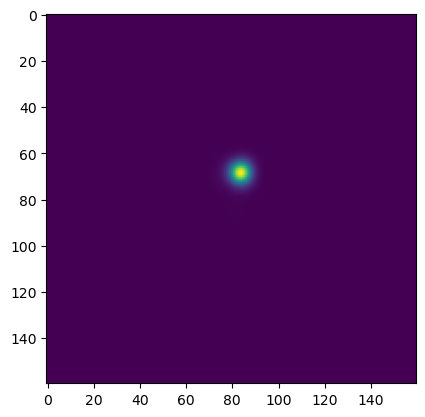

In [55]:
plt.imshow(psfarrs[512])

  0%|          | 0/15000 [00:00<?, ?it/s]

resid std: 0.00050307304 relative to image: 0.9999618


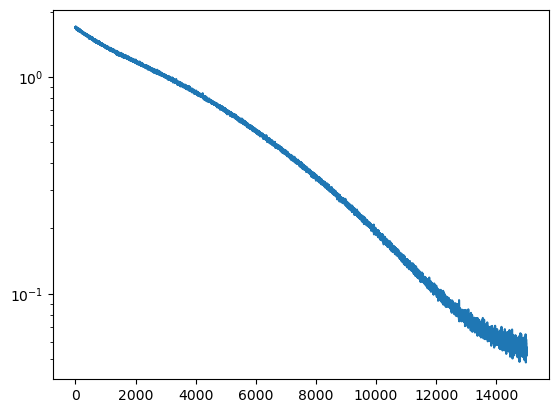

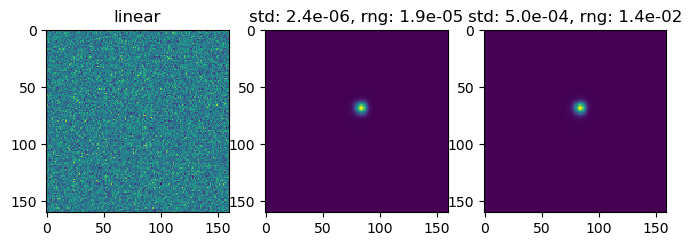

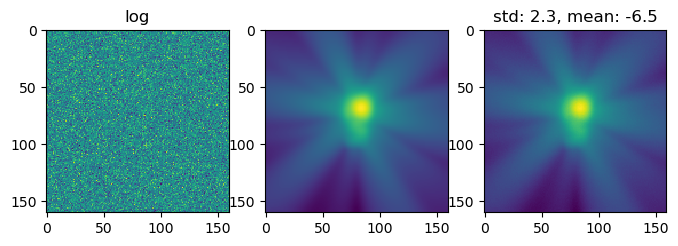

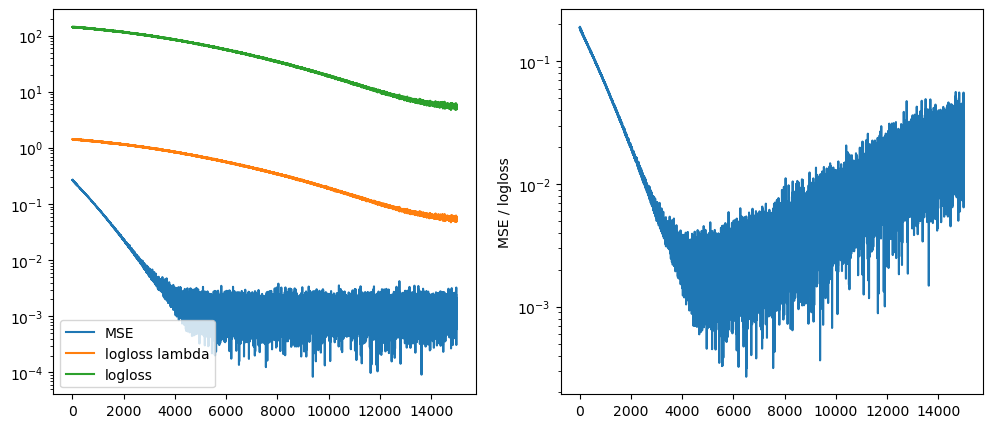

In [57]:
LEARNING_RATE = 1e-3
EPOCHS = 15000
BATCH_SIZE = 2048

LOSS_LOG_LAMBDA = 1e-2

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFFINER(n_in_coo=2, omega0=1)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

mselosses = jnp.ones((EPOCHS,)) * jnp.nan
losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    xi = xs[batch_idx]
    yi = ys[batch_idx]
    mselosses = mselosses.at[i].set(mse_loss_fn(model, xi, yi))
    model, opt_state, loss_value = make_step(model, opt_state, xi, yi, optimizer.update, losslamb=LOSS_LOG_LAMBDA)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])
rnpred = pred / pred.sum()
rnpsf = psf / psf.sum()
diff = rnpsf - rnpred

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(rnpred, interpolation='nearest')
ax2.imshow(rnpsf, interpolation='nearest')
ax3.imshow(diff, interpolation='nearest')

ax2.set_title(f'std: {rnpred.std():.1e}, rng: {rnpred.max()-rnpred.min():.1e}')
ax3.set_title(f'std: {diff.std():.1e}, rng: {diff.max()-diff.min():.1e}')

ax1.set_title('linear')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 16))
ax1.imshow(jnp.log(rnpred), interpolation='nearest')
ax2.imshow(jnp.log(rnpsf), interpolation='nearest')
ldiff = jnp.log(rnpsf) - jnp.log(rnpred)
ax3.imshow(ldiff, interpolation='nearest')
ax3.set_title(f'std: {ldiff.std():.2}, mean: {ldiff.mean():.2}')
ax1.set_title('log')

print('resid std:', diff.std(), 'relative to image:', diff.std()/rnpsf.std())

# compare the different loss function compnents
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
loglossesl = losses - mselosses
loglosses = loglossesl / LOSS_LOG_LAMBDA
ax1.semilogy(mselosses, label='MSE')
ax1.semilogy(loglossesl, label='logloss lambda')
ax1.semilogy(loglosses, label='logloss')
ax1.legend(loc=0)

ax2.semilogy(mselosses/loglossesl)
ax2.set_ylabel('MSE / logloss');

Ok that's the right general idea!  Is it fast enough evaluation?

In [58]:
vm = jax.jit(jax.vmap(model))
vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

%timeit vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

E0701 13:14:41.160749   39224 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.1 = f32[25600,256]{1,0} fusion(mul.3, constant.17), kind=kCustom, calls=gemm_fusion_dot.1_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0701 13:14:41.160864   39224 xtile_compiler.cc:401] Computation: gemm_fusion_dot.1_computation.clone {
  parameter_0.1 = f32[25600,256]{1,0} parameter(0)
  sin.0 = f32[25600,256]{1,0} sine(parameter_0.1)
  parameter_1.1 = f32[256,256]{1,0} parameter(1)
  ROOT dot.5 = f32[25600,256]{1,0} dot(sin.0, parameter_1.1), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}


428 μs ± 3.85 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


That doesn't really meaningfully improve on the others. If I skip the finer-style initialization it works better but not notably better so don't bother.